# NGSolve User Meeting: Sphere Volume/Area p-Convergence

This validation notebook keeps the Cubit-free OCC path as durable numerical evidence. The ACIS demo copy lives beside this notebook. It verifies the native OCC path: `Sphere -> Netgen mesh -> mesh.Curve(p) -> Integrate(1)` for volume and boundary area.

The historical example also tried the Cubit ACIS callback trampoline. That path is intentionally not run here because the current `cubit_mesh_export` public API no longer exposes the old `extract_curved_mesh` helper used by the presentation script. The robust, reusable result kept here is the OCC p-convergence reference.

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'volume_area_convergence.py').exists():
    NOTEBOOK_DIR = Path('validation_test/ngsolve_user_meeting').resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))

from volume_area_convergence import run_occ_convergence, write_results_json, format_rows

result = run_occ_convergence()
json_path = write_results_json(result, NOTEBOOK_DIR / 'volume_area_convergence_results.json')
print(format_rows(result['rows']))
print(f'\nwrote {json_path.relative_to(NOTEBOOK_DIR)}')

case      p      ne    V err (%)    A err (%)  curve (s)
coarse    1     402    -3.544753    -1.972965     0.0000
coarse    2     402    -0.025361    -0.016795     0.0014
coarse    3     402    +0.002410    +0.001642     0.0091
coarse    4     402    +0.000040    +0.000027     0.0117
coarse    5     402    -0.000001    -0.000003     0.0148
fine      1    4931    -1.013835    -0.561583     0.0000
fine      2    4931    -0.002064    -0.001373     0.0051
fine      3    4931    +0.000203    +0.000136     0.0344
fine      4    4931    +0.000001    +0.000001     0.0421
fine      5    4931    -0.000000    -0.000000     0.0522

wrote volume_area_convergence_results.json


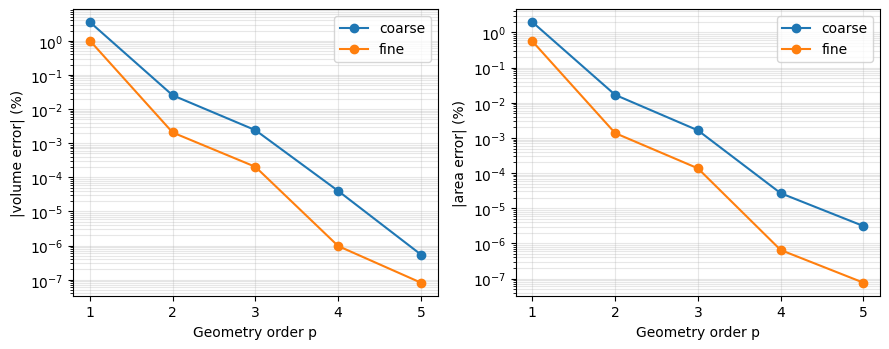

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharex=True)
for case in sorted({row['case'] for row in result['rows']}):
    rows = [row for row in result['rows'] if row['case'] == case]
    orders = [row['order'] for row in rows]
    axes[0].semilogy(orders, [abs(row['volume_error_percent']) for row in rows], marker='o', label=case)
    axes[1].semilogy(orders, [abs(row['area_error_percent']) for row in rows], marker='o', label=case)

axes[0].set_xlabel('Geometry order p')
axes[0].set_ylabel('|volume error| (%)')
axes[1].set_xlabel('Geometry order p')
axes[1].set_ylabel('|area error| (%)')
for ax in axes:
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
fig.tight_layout()
plt.show()

The expected pattern is the one used in the NGSolve/Cubit curving workflow: the linear mesh has percent-level geometric error, while the curved geometry rapidly reaches near-exact volume and area integration. The durable numeric record is `volume_area_convergence_results.json`; the notebook output is the rendered view.